In [44]:
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

In [45]:
!kaggle datasets download paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [46]:
!unzip chest-xray-pneumonia.zip

Archive:  chest-xray-pneumonia.zip
replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [47]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix


In [49]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150
def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size)) # Reshaping images to preferred size
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data)

In [50]:
train_dir = 'chest_xray/train'
test_dir  = 'chest_xray/test'
val_dir   = 'chest_xray/val'

In [67]:
import cv2
import numpy as np

IMG_SIZE = 150

# ── Load Train ────────────────────────────────────────────────────────────────
x_train, y_train = [], []
for label, category in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(train_dir, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        x_train.append(img)
        y_train.append(label)

# ── Load Test ─────────────────────────────────────────────────────────────────
x_test, y_test = [], []
for label, category in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(test_dir, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        x_test.append(img)
        y_test.append(label)

# ── Load Val ──────────────────────────────────────────────────────────────────
x_val, y_val = [], []
for label, category in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(val_dir, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        x_val.append(img)
        y_val.append(label)

# ── Convert & Normalize ───────────────────────────────────────────────────────
x_train = np.array(x_train).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
x_test  = np.array(x_test).reshape(-1, IMG_SIZE, IMG_SIZE, 1)  / 255.0
x_val   = np.array(x_val).reshape(-1, IMG_SIZE, IMG_SIZE, 1)   / 255.0

y_train = np.array(y_train)
y_test  = np.array(y_test)
y_val   = np.array(y_val)

# ── Check ─────────────────────────────────────────────────────────────────────
print(f"✅ Done!")
print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}  | y_test:  {y_test.shape}")
print(f"x_val:   {x_val.shape}   | y_val:   {y_val.shape}")

✅ Done!
x_train: (5216, 150, 150, 1) | y_train: (5216,)
x_test:  (624, 150, 150, 1)  | y_test:  (624,)
x_val:   (16, 150, 150, 1)   | y_val:   (16,)


In [52]:
for folder in ['train', 'test', 'val']:
    path = f'chest_xray/{folder}'
    classes = os.listdir(path)
    print(f'{folder}: {classes}')
    for c in classes:
        count = len(os.listdir(f'{path}/{c}'))
        print(f'  {c}: {count} images')

train: ['NORMAL', 'PNEUMONIA']
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
test: ['NORMAL', 'PNEUMONIA']
  NORMAL: 234 images
  PNEUMONIA: 390 images
val: ['NORMAL', 'PNEUMONIA']
  NORMAL: 8 images
  PNEUMONIA: 8 images


# Data Visualization & Preprocessing

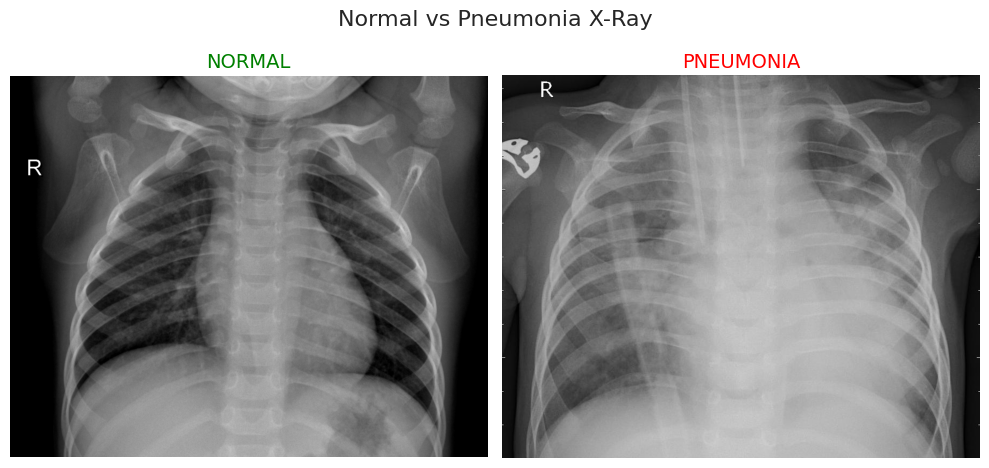

In [53]:
#Show sample images from each class:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Normal
normal_img = cv2.imread(os.path.join(train_dir, 'NORMAL',
             os.listdir(os.path.join(train_dir, 'NORMAL'))[0]))
normal_img = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(normal_img)
axes[0].set_title('NORMAL', color='green', fontsize=14)
axes[0].axis('off')

# Pneumonia
pneumonia_img = cv2.imread(os.path.join(train_dir, 'PNEUMONIA',
                os.listdir(os.path.join(train_dir, 'PNEUMONIA'))[0]))
pneumonia_img = cv2.cvtColor(pneumonia_img, cv2.COLOR_BGR2RGB)
axes[1].imshow(pneumonia_img)
axes[1].set_title('PNEUMONIA', color='red', fontsize=14)
axes[1].axis('off')

plt.suptitle('Normal vs Pneumonia X-Ray', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4240/3497892178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Pneumonia'],


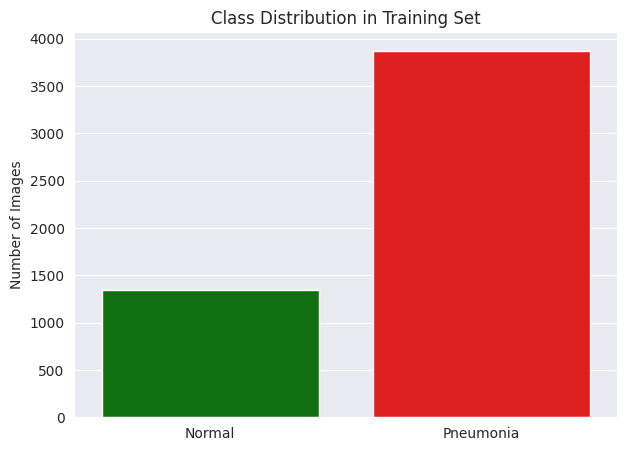

Normal: 1341 images
Pneumonia: 3875 images


In [54]:
#Class distribution:
normal_count = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))

plt.figure(figsize=(7,5))
sns.barplot(x=['Normal', 'Pneumonia'],
            y=[normal_count, pneumonia_count],
            palette=['green', 'red'])
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of Images')
plt.show()

print(f"Normal: {normal_count} images")
print(f"Pneumonia: {pneumonia_count} images")

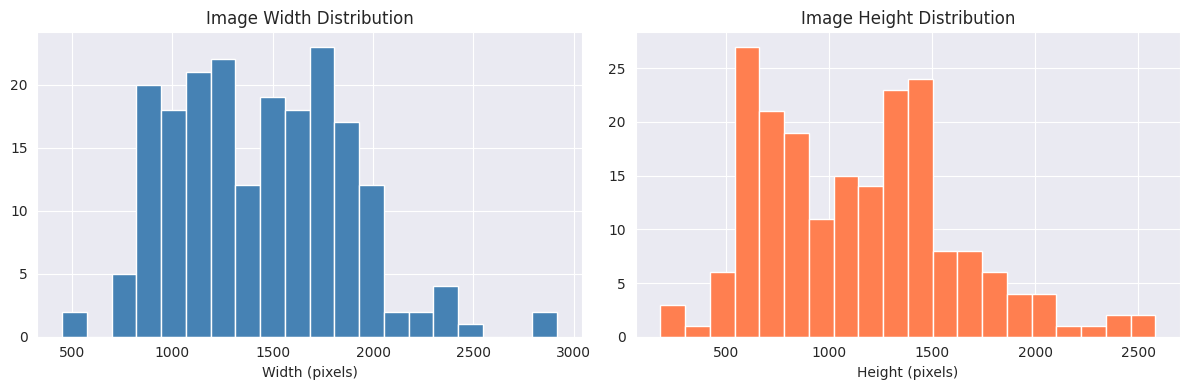

In [55]:
#Image size distribution:
widths, heights = [], []

for category in ['NORMAL', 'PNEUMONIA']:
    folder = os.path.join(train_dir, category)
    for img_name in random.sample(os.listdir(folder), 100):
        img = cv2.imread(os.path.join(folder, img_name))
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color='steelblue')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')

axes[1].hist(heights, bins=20, color='coral')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')

plt.tight_layout()
plt.show()

In [68]:
x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# Data Augmentation


In [69]:
# With data augmentation to prevent overfitting and handling the imbalance in dataset

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

For the data augmentation, i choosed to :

Randomly rotate some training images by 30 degrees
Randomly Zoom by 20% some training images
Randomly shift images horizontally by 10% of the width
Randomly shift images vertically by 10% of the height
Randomly flip images horizontally. Once our model is ready, we fit the training dataset.

# Training the Model


In [70]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [71]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [72]:
history = model.fit(datagen.flow(x_train,y_train, batch_size = 32) ,epochs = 12 , validation_data = datagen.flow(x_val, y_val) ,callbacks = [learning_rate_reduction])

Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step - accuracy: 0.8282 - loss: 0.5558 - val_accuracy: 0.5000 - val_loss: 95.6987 - learning_rate: 0.0010
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9018 - loss: 0.2634 - val_accuracy: 0.5000 - val_loss: 61.4496 - learning_rate: 0.0010
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9126 - loss: 0.2365
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.9158 - loss: 0.2305 - val_accuracy: 0.5000 - val_loss: 61.8438 - learning_rate: 0.0010
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9477 - loss: 0.1453 - val_accuracy: 0.5625 - val_loss: 6.0597 - learning_rate: 3.0000e-04
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9482 - loss: 0.1388 - val_accuracy: 0.5000 - val_loss: 8.4724 - learning_rate: 3.0000e-04
Epoch 6/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.

In [73]:
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9151 - loss: 0.2463
Loss of the model is -  0.24633446335792542
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9151 - loss: 0.2463
Accuracy of the model is -  91.50640964508057 %


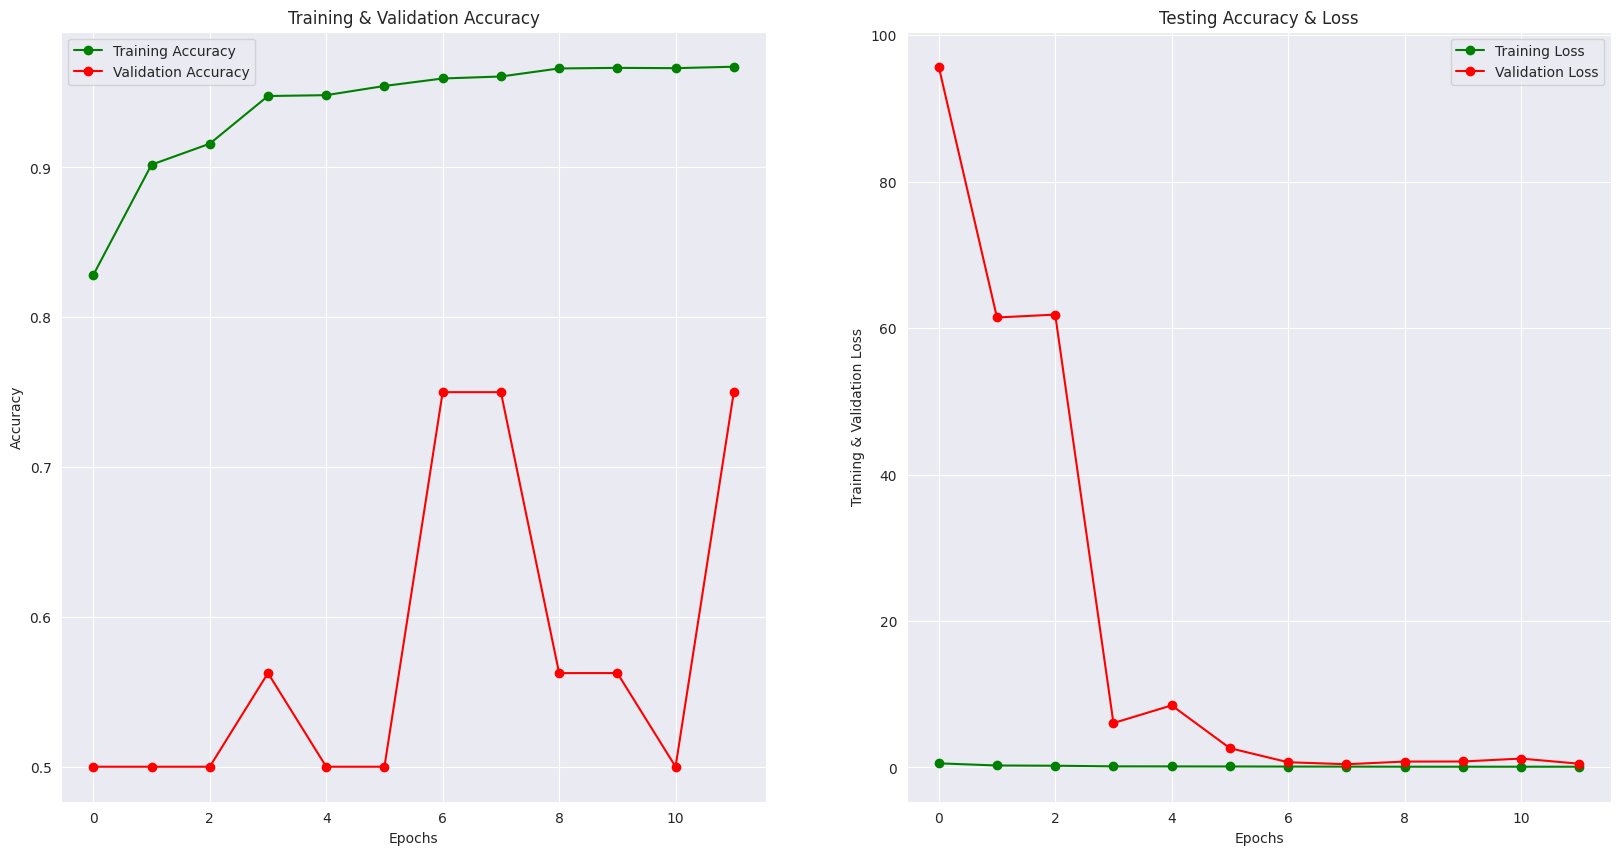

In [74]:
epochs = [i for i in range(12)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training & Validation Loss")
plt.show()

In [77]:
predictions = (model.predict(x_test) > 0.5).astype(int)
predictions = predictions.reshape(1, -1)[0]

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


In [78]:
# ── Classification Report ─────────────────────────────────────────────────────
print(classification_report(y_test, predictions,
      target_names=['Normal', 'Pneumonia']))


              precision    recall  f1-score   support

      Normal       0.89      0.89      0.89       234
   Pneumonia       0.93      0.93      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



In [94]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9151 - loss: 0.2463
Test Loss:     0.2463
Test Accuracy: 91.51%


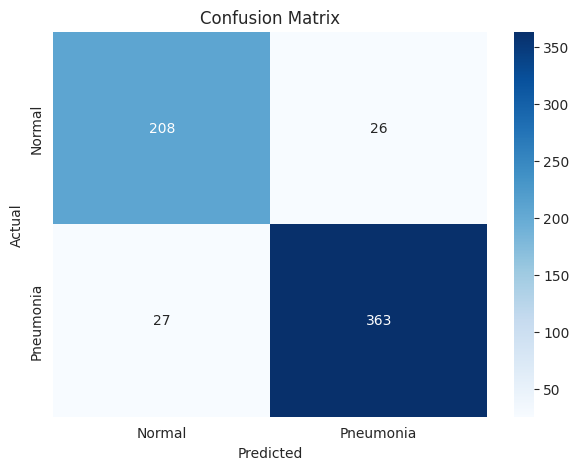

In [79]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [82]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

Some of the Correctly Predicted Classes



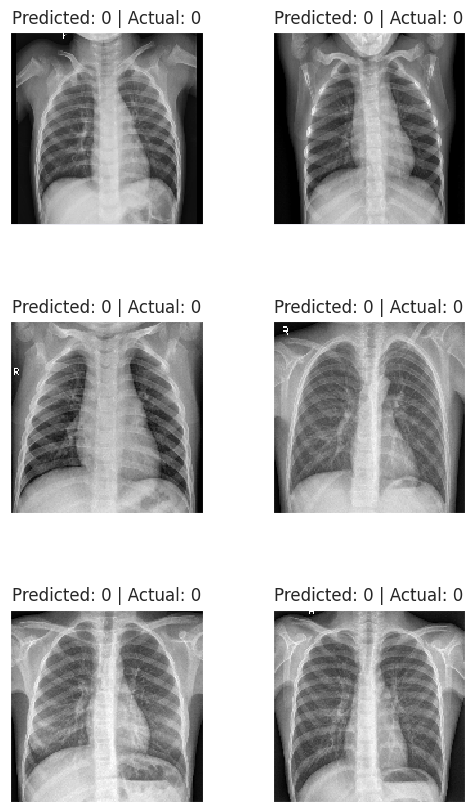

In [92]:
plt.figure(figsize=(6, 10))
i = 0
for c in correct[:6]:
    plt.subplot(3, 2, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted: {} | Actual: {}".format(predictions[c], y_test[c]),
              fontsize=12)
    i += 1

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

Some of the Incorrectly Predicted Classes



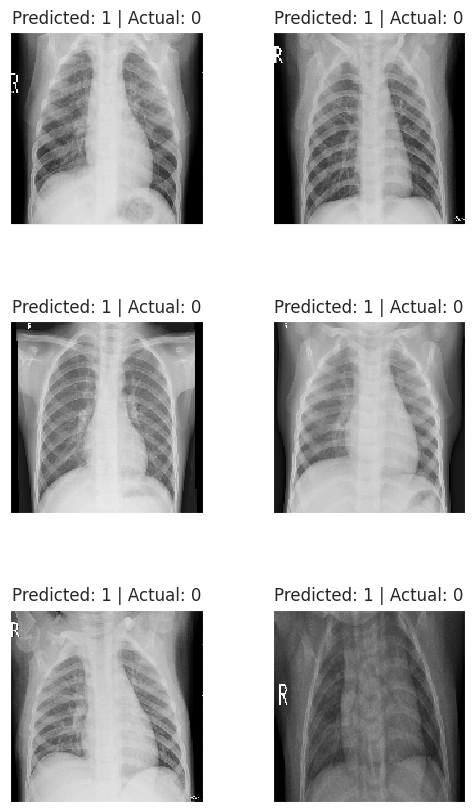

In [93]:
plt.figure(figsize=(6, 10))
i = 0
for c in incorrect[:6]:
    plt.subplot(3, 2, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted: {} | Actual: {}".format(predictions[c], y_test[c]),
              fontsize=12)
    i += 1

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()